# 01 - Email Classifier with LangGraph

We will build this notebook step by step.

In Step 1, we only set up the environment and verify that local Ollama is ready.

### Step 1 - Environment Setup

Purpose: install the Python packages we need and confirm that Ollama can serve the local models.

We are using local Ollama only. No OpenAI API keys are needed.

In [1]:
# Install the core packages for this notebook.
# Run this cell once. If everything is already installed, pip will say so.

%pip install -r requirements.txt


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Check that the packages import correctly.

import langchain
import langgraph
import pydantic

print("langchain:", langchain.__version__)
print("langgraph imported successfully")
print("pydantic:", pydantic.__version__)

langchain: 1.2.17
langgraph imported successfully
pydantic: 2.13.3


In [3]:
# Verify that the Ollama server is running locally.
# This should return JSON with available local models.

import requests

OLLAMA_BASE_URL = "http://localhost:11434"

try:
    response = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=5)
    response.raise_for_status()
    print("Ollama is running.")
except requests.exceptions.RequestException as error:
    print("Ollama check failed.")
    print("Start Ollama first, then run this cell again.")
    print("Error:", error)

Ollama is running.


In [4]:
# Verify that the required models are available in Ollama.
# Main chat model: qwen2.5:14b
# Embedding model for later RAG work: nomic-embed-text

required_models = {"qwen2.5:14b", "nomic-embed-text"}

try:
    response = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=5)
    response.raise_for_status()

    models = response.json().get("models", [])
    available_model_names = {model.get("name") for model in models}

    # Ollama may show models with tags, like "nomic-embed-text:latest".
    # This lets us accept both "nomic-embed-text" and "nomic-embed-text:latest".
    available_model_base_names = {
        model_name.split(":")[0]
        for model_name in available_model_names
        if model_name
    }

    print("Available Ollama models:")
    for model_name in sorted(available_model_names):
        print("-", model_name)

    missing_models = {
        model_name
        for model_name in required_models
        if (
            model_name not in available_model_names
            and model_name not in available_model_base_names
        )
    }

    if missing_models:
        print("\nMissing required model(s):")
        for model_name in sorted(missing_models):
            print("-", model_name)

        print("\nInstall missing models with:")
        for model_name in sorted(missing_models):
            print(f"ollama pull {model_name}")
    else:
        print("\nAll required models are available.")

except requests.exceptions.RequestException as error:
    print("Could not read Ollama model list.")
    print("Error:", error)


Available Ollama models:
- nomic-embed-text:latest
- qwen2.5-coder:14b-instruct
- qwen2.5-coder:7b-instruct
- qwen2.5:14b

All required models are available.


#### Simple LangChain Ollama Call

In [5]:
from langchain_ollama import ChatOllama
llm = ChatOllama(
    model = 'qwen2.5:14b',
    temperature = 0
)

response = llm.invoke("You are helping test a local AI support email classifier. Reply with exactly: Ollama is working.")
print("LLM response:", response)
print("LLM Content:", response.content)

LLM response: content='Ollama is working.' additional_kwargs={} response_metadata={'model': 'qwen2.5:14b', 'created_at': '2026-05-09T08:59:01.976575Z', 'done': True, 'done_reason': 'stop', 'total_duration': 10886364375, 'load_duration': 9343295292, 'prompt_eval_count': 50, 'prompt_eval_duration': 830210250, 'eval_count': 7, 'eval_duration': 698718500, 'logprobs': None, 'model_name': 'qwen2.5:14b', 'model_provider': 'ollama'} id='lc_run--019e0bf5-fd50-7102-ab45-ece443e20349-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 50, 'output_tokens': 7, 'total_tokens': 57}
LLM Content: Ollama is working.


No History involve in this

In [6]:
response = llm.invoke("My name is nikhilesh Sirohi. How are you?")
print("LLM Response:", response)

print("\n***********************\n")
response = llm.invoke("What is my Name?")
print("LLM Response:", response)

LLM Response: content="Hello Nikhilesh Sirohi! It's nice to meet you. I'm just a computer program, so I don't have feelings like humans do, but thank you for asking! How can I assist you today?" additional_kwargs={} response_metadata={'model': 'qwen2.5:14b', 'created_at': '2026-05-09T08:59:56.924006Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6969726959, 'load_duration': 94753750, 'prompt_eval_count': 44, 'prompt_eval_duration': 486775000, 'eval_count': 47, 'eval_duration': 6349006083, 'logprobs': None, 'model_name': 'qwen2.5:14b', 'model_provider': 'ollama'} id='lc_run--019e0bf6-e33d-7751-8ef3-bbe39f03d70d-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 44, 'output_tokens': 47, 'total_tokens': 91}

***********************

LLM Response: content="I'm sorry, but as an artificial intelligence, I don't have access to information that isn't provided to me in the conversation. You haven't told me your name, so I don't know what it is. Could you please te

### Create The Pydantic Output Schema

define the final JSON shape we want from the email classifier

Purpose: define the final JSON shape we want from the email classifier. This gives us a clean contract before we build the LangGraph node

In [7]:
from pydantic import BaseModel, Field
from typing import Literal

class EmailClassificationResult(BaseModel):
    problem_type: str = Field(
        description = "The main type of customer problem, such as Delivery Issue, Billing Issue, Technical Issue, or General Inquiry."
    )
    urgency: Literal['Low', 'Medium', 'High'] = Field(
        description = "How urgent the customer issue is."
    )
    sentiment: Literal['Negative', 'Neutral', 'Positive'] = Field(
        description = "The customer's emotional tone."
    )
    route_to: str = Field(
        description = "The support team that should handle this issue."
    )
    summary: str = Field(
        description = "A short summary of the customer's mail."
    )
    next_action: str = Field(
        description = "The recommended next action for the support team."
    )

test the above cell

In [8]:
sample_result = EmailClassificationResult(
    problem_type="Delivery Issue",
    urgency="High",
    sentiment="Negative",
    route_to="Logistics Team",
    summary="Customer is reporting a 3-day delivery delay and needs an urgent update.",
    next_action="Create high-priority ticket and notify logistics team.",
)

print("Sample EmailClassificationResult:")
print(sample_result.model_dump_json(indent=2))

Sample EmailClassificationResult:
{
  "problem_type": "Delivery Issue",
  "urgency": "High",
  "sentiment": "Negative",
  "route_to": "Logistics Team",
  "summary": "Customer is reporting a 3-day delivery delay and needs an urgent update.",
  "next_action": "Create high-priority ticket and notify logistics team."
}


### Create The LangGraph State

Purpose: LangGraph needs a shared “state” object. Think of it as a dictionary that gets passed from node to node. Each node reads some fields and adds or updates others.

In [10]:
from typing import TypedDict, Optional

class EmailAgentState(TypedDict):
    email_text: str
    problem_type: Optional[str]
    urgency: Optional[str]
    sentiment: Optional[str]
    route_to: Optional[str]
    summary: Optional[str]
    next_action: Optional[str]
    final_output: Optional[EmailClassificationResult]


In [11]:
sample_state: EmailAgentState = {
    "email_text": "Hi team, our delivery has been delayed for 3 days. The client is angry and asking for an update immediately.",
    "problem_type": None,
    "urgency": None,
    "sentiment": None,
    "route_to": None,
    "summary": None,
    "next_action": None,
    "final_output": None,
}

print(sample_state)

{'email_text': 'Hi team, our delivery has been delayed for 3 days. The client is angry and asking for an update immediately.', 'problem_type': None, 'urgency': None, 'sentiment': None, 'route_to': None, 'summary': None, 'next_action': None, 'final_output': None}


###  First LangGraph Node - classify_problem_node
Purpose: this node reads the email text and predicts the main problem type. For now, it only fills problem_type in the state.

In [27]:
def classify_problem_node(state: EmailAgentState) -> EmailAgentState:
    prompt = f"""
You are a support email classification assistant.

Classify the customer's problem type from the email below.

Allowed examples:
- Delivery Issue
- Billing Issue
- Technical Issue
- Account Issue
- Product Quality Issue
- Refund Request
- General Inquiry

Rules:
- Return only the problem type.
- Do not explain your answer.
- Do not return JSON.

Email:
{state["email_text"]}
"""

    response = llm.invoke(prompt)
    problem_type = clean_label(
        response.content,
        allowed_values=[
            "Delivery Issue",
            "Billing Issue",
            "Technical Issue",
            "Account Issue",
            "Product Quality Issue",
            "Refund Request",
            "General Inquiry",
        ],
        default_value="General Inquiry",
    )
    # problem_type = response.content.strip()
    return {
        # **state,
        "problem_type": problem_type,
    }


In [52]:
test_state = {
    "email_text": "Hi team, our delivery has been delayed for 3 days. The client is angry and asking for an update immediately.",
    "problem_type": None,
    "urgency": None,
    "sentiment": None,
    "route_to": None,
    "summary": None,
    "next_action": None,
    "final_output": None,
}

result_state = classify_problem_node(test_state)

print("Problem Type:", result_state["problem_type"])


Problem Type: Delivery Issue


### Second Node - urgency_node
Purpose: this node reads the email and detects urgency as only one of three values: Low, Medium, or High.

In [24]:
def clean_label(raw_text: str, allowed_values: list[str], default_value: str) -> str:
    cleaned_text = raw_text.strip()

    for value in allowed_values:
        if cleaned_text.lower() == value.lower():
            return value

    for value in allowed_values:
        if value.lower() in cleaned_text.lower():
            return value

    return default_value


In [25]:
def urgency_node(state: EmailAgentState) -> EmailAgentState:
    prompt = f"""
You are a strict support email urgency classifier.

Classify the urgency of the customer email.

Allowed urgency values:
- Low
- Medium
- High

Rules:
- Return only one value: Low, Medium, or High.
- Do not explain your answer.
- Do not return JSON.
- Do not mark an issue as High only because the customer has a problem.
- Most normal support issues are Medium unless there is clear immediate impact.

Use this decision guide:

High:
- customer explicitly says urgent, immediately, ASAP, emergency, critical, escalation, legal action, or angry client
- service is down or business operations are blocked
- payment failure is causing service loss
- major delay with an angry client or immediate update request
- security or account takeover risk

Medium:
- customer cannot use a feature, but no business outage is mentioned
- login problem without security risk
- damaged product or delivery problem without urgent deadline
- duplicate charge or refund request without escalation
- customer is frustrated but no immediate business impact is described

Low:
- general questions
- invoice download requests
- informational requests
- simple status checks without urgency

Email:
{state["email_text"]}
"""

    response = llm.invoke(prompt)
    urgency = clean_label(
        response.content,
        allowed_values=["Low", "Medium", "High"],
        default_value="Medium",
    )
    # urgency = response.content.strip()

    return {
        "urgency": urgency,
    }


In [54]:
test_state = classify_problem_node(test_state)
test_state = urgency_node(test_state)

print("Problem Type:", test_state["problem_type"])
print("Urgency:", test_state["urgency"])


KeyError: 'email_text'

### Third Node - sentiment_node
Purpose: this node detects the customer’s emotional tone as Positive, Neutral, or Negative

In [26]:
def sentiment_node(state: EmailAgentState) -> EmailAgentState:
    prompt = f"""
You are a support email sentiment detection assistant.

Detect the customer's sentiment from the email below.

Allowed sentiment values:
- Positive
- Neutral
- Negative

Rules:
- Return only one value: Positive, Neutral, or Negative.
- Do not explain your answer.
- Do not return JSON.

Guidance:
- Negative means the customer is unhappy, angry, frustrated, disappointed, or worried.
- Neutral means the customer is simply asking or reporting without strong emotion.
- Positive means the customer is satisfied, thankful, or expressing appreciation.

Email:
{state['email_text']}
"""
    response = llm.invoke(prompt)
    sentiment = clean_label(
        response.content,
        allowed_values=["Positive", "Neutral", "Negative"],
        default_value="Neutral",
    )
    # sentiment = response.content.strip()

    return {
        # **state,
        "sentiment": sentiment,
    }

In [40]:
test_state = sentiment_node(test_state)

print("Problem Type:", test_state["problem_type"])
print("Urgency:", test_state["urgency"])
print("Sentiment:", test_state["sentiment"])


Problem Type: Delivery Issue
Urgency: High
Sentiment: Negative


###  Fourth Node - route_node
Purpose: this node decides which support team should handle the email.
This node uses the earlier result problem_type. Later, in production, routing could become rule-based, database-driven, or configurable by an admin. For now, we’ll keep it simple and understandable.

In [15]:
def route_node(state: EmailAgentState) -> EmailAgentState:
    prompt = f"""
You are a support ticket routing assistant.

Decide which internal support team should handle this issue.

Use the problem type and email below.

Problem Type:
{state['problem_type']}

Email:
{state['email_text']}

Allowed routing examples:
- Logistics Support Team
- Billing Support Team
- Technical Support Team
- Account Support Team
- Product Support Team
- Refund Support Team
- General Support Team

Rules:
- Return only the team name.
- Do not explain your answer.
- Do not return JSON.
"""
    response = llm.invoke(prompt)
    route_to = response.content.strip()

    return {
        # **state,
        "route_to": route_to,
    }

In [42]:
test_state = route_node(test_state)

print("Problem Type:", test_state["problem_type"])
print("Urgency:", test_state["urgency"])
print("Sentiment:", test_state["sentiment"])
print("Route To:", test_state["route_to"])


Problem Type: Delivery Issue
Urgency: High
Sentiment: Negative
Route To: Logistics Support Team


### final_response_node

Purpose: this node creates the final structured output using the fields we already collected.

This node will:

create a short summary
create a recommended next action
build a valid EmailClassificationResult Pydantic object
store it in state["final_output"]

In [16]:
import json

def final_response_node(state: EmailAgentState) -> EmailAgentState:
    prompt = f"""
You are a support operations assistant.

Create a short summary and next action for this customer email.

Email:
{state['email_text']}

Known analysis:
- Problem Type: {state["problem_type"]}
- Urgency: {state["urgency"]}
- Sentiment: {state["sentiment"]}
- Route To: {state["route_to"]}

Return only valid JSON with exactly these keys:
{{
  "summary": "...",
  "next_action": "..."
}}

Rules:
- Do not include markdown.
- Do not include explanations.
- The summary should be one sentence.
- The next_action should be one clear operational action.
"""
    
    response = llm.invoke(prompt)
    raw_text = response.content.strip()

    try:
        parsed = json.loads(raw_text)
        final_output = EmailClassificationResult(
            problem_type = state["problem_type"],
            urgency = state["urgency"],
            sentiment = state["sentiment"],
            route_to = state["route_to"],
            summary = parsed.get("summary", ""),
            next_action = parsed.get("next_action", ""),
        )

        return {
            # **state,
            "summary": final_output.summary,
            "next_action": final_output.next_action,
            "final_output": final_output,
        }
    
    except Exception as error:
        print("JSON parsing or validation failed.")
        print("Raw model response:")
        print(raw_text)
        print("Error:", error)

        return {
            # **state,
            "summary": None,
            "next_action": None,
            "final_output": None,
        }


In [47]:
test_state = final_response_node(test_state)

if test_state["final_output"] is not None:
    print(test_state["final_output"].model_dump_json(indent=2))
else:
    print("Final output was not created.")


{
  "problem_type": "Delivery Issue",
  "urgency": "High",
  "sentiment": "Negative",
  "route_to": "Logistics Support Team",
  "summary": "Client is upset due to a 3-day delivery delay and requires an immediate update.",
  "next_action": "Contact the Logistics Support Team to expedite resolution and provide an urgent update to the client."
}


# Build The LangGraph Workflow
Purpose: now we connect the nodes into an actual graph

In [28]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(EmailAgentState)

workflow.add_node("classify_problem", classify_problem_node)
workflow.add_node("detect_urgency", urgency_node)
workflow.add_node("detect_sentiment", sentiment_node)
workflow.add_node("route_node", route_node)
workflow.add_node("final_response_node", final_response_node)

# These three nodes can run in parallel because they only need email_text.
workflow.add_edge(START, "classify_problem")
workflow.add_edge(START, "detect_urgency")
workflow.add_edge(START, "detect_sentiment")

# route_ticket needs problem_type, so it runs after classify_problem.
workflow.add_edge("classify_problem", "route_node")

# final_response_node needs problem_type, urgency, sentiment, and route_to.
# workflow.add_edge("route_node", "final_response_node")
# workflow.add_edge("detect_urgency", "final_response_node")
# workflow.add_edge("detect_sentiment", "final_response_node")
workflow.add_edge(
    ["route_node", "detect_urgency", "detect_sentiment"],
    "final_response_node",
)

workflow.add_edge("final_response_node", END)

email_agent = workflow.compile()

print("Parallel Email classification LangGraph workflow compiled successfully.")


Parallel Email classification LangGraph workflow compiled successfully.


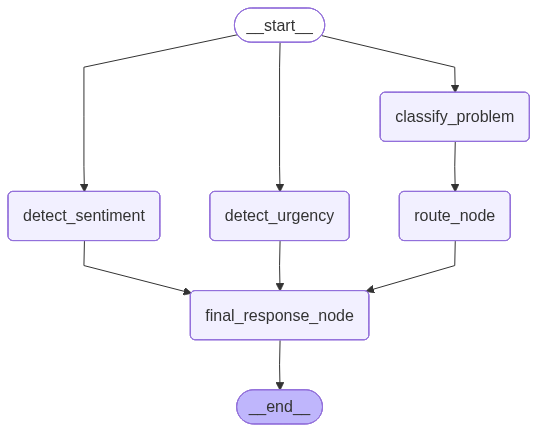

In [29]:
email_agent

### Run The Full LangGraph Agent
Purpose: now we test the complete workflow from raw email to final structured JSON.

In [19]:
initial_state: EmailAgentState = {
    'email_text': "Hi team, our delivery has been delayed for 3 days. The client is angry and asking for an update immediately.",
    'problem_type': None,
    'urgency': None,
    'sentiment': None,
    'route_to': None,
    'summary': None,
    'next_action': None,
    'final_output': None,
}

final_state = email_agent.invoke(initial_state)

if final_state["final_output"] is not None:
    print("Final classification result:")
    print(final_state["final_output"].model_dump_json(indent=2))
else:
    print("Final output was not created.")

Final classification result:
{
  "problem_type": "Delivery Issue",
  "urgency": "High",
  "sentiment": "Negative",
  "route_to": "Logistics Support Team",
  "summary": "Client is upset due to a 3-day delivery delay and requires an immediate update.",
  "next_action": "Contact the Logistics Support Team to expedite resolution and provide an urgent update to the client."
}


### Add A Small Reusable Runner Function

Purpose: instead of rewriting initial_state every time, we’ll create a simple function that accepts any dummy email and returns structured JSON.

In [20]:
def classify_email(email_text: str) -> EmailClassificationResult | None:
    initial_state: EmailAgentState = {
        "email_text": email_text,
        "problem_type": None,
        "urgency": None,
        "sentiment": None,
        "route_to": None,
        "summary": None,
        "next_action": None,
        "final_output": None,
    }

    final_state = email_agent.invoke(initial_state)

    return final_state["final_output"]


In [21]:
sample_email = """
Hello, I was charged twice for my monthly subscription.
Please help me fix this billing issue.
"""

result = classify_email(sample_email)

if result is not None:
    print(result.model_dump_json(indent=2))
else:
    print("Could not classify the email.")


{
  "problem_type": "Billing Issue",
  "urgency": "Medium",
  "sentiment": "Negative",
  "route_to": "Billing Support Team",
  "summary": "Customer reported being charged twice for their monthly subscription and requires assistance to resolve the billing issue.",
  "next_action": "Forward the case to the Billing Support Team to investigate and correct the double charge."
}


### Test With Multiple Dummy Emails

Purpose: now we’ll check whether the workflow behaves reasonably across different problem types. This helps us find prompt weaknesses early.

In [30]:
dummy_emails = [
    "Hi, I cannot log into my account even after resetting my password twice.",
    "The product arrived damaged and the packaging was torn.",
    "Can you tell me where I can download my invoice for last month?",
    "Our payment failed and our service is down. We need this fixed immediately.",
]

for index, email_text in enumerate(dummy_emails, start=1):
    print(f"\n--- Email {index} ---")
    print(email_text)

    result = classify_email(email_text)

    if result is not None:
        print(result.model_dump_json(indent=2))
    else:
        print("Could not classify this email.")



--- Email 1 ---
Hi, I cannot log into my account even after resetting my password twice.
{
  "problem_type": "Account Issue",
  "urgency": "Medium",
  "sentiment": "Negative",
  "route_to": "Account Support Team",
  "summary": "Customer is unable to log into their account despite resetting the password twice.",
  "next_action": "Forward the issue to the Account Support Team for further investigation and resolution."
}

--- Email 2 ---
The product arrived damaged and the packaging was torn.
{
  "problem_type": "Product Quality Issue",
  "urgency": "Medium",
  "sentiment": "Negative",
  "route_to": "Product Support Team",
  "summary": "Customer received a damaged product with torn packaging.",
  "next_action": "Forward the case to the Product Support Team for further investigation and resolution."
}

--- Email 3 ---
Can you tell me where I can download my invoice for last month?
{
  "problem_type": "Billing Issue",
  "urgency": "Low",
  "sentiment": "Neutral",
  "route_to": "Billing Sup

### Add A Final Clean Demo Cell

Purpose: this is the cell you can show later as the final working result of Notebook 1. It uses one input email and prints clean structured JSON

In [31]:
demo_email = """
Hi team, our delivery has been delayed for 3 days.
The client is angry and asking for an update immediately.
"""

demo_result = classify_email(demo_email)

print("Input Email:")
print(demo_email.strip())

print("\nStructured Output:")

if demo_result is not None:
    print(demo_result.model_dump_json(indent=2))
else:
    print("Could not classify the email.")


Input Email:
Hi team, our delivery has been delayed for 3 days.
The client is angry and asking for an update immediately.

Structured Output:
{
  "problem_type": "Delivery Issue",
  "urgency": "High",
  "sentiment": "Negative",
  "route_to": "Logistics Support Team",
  "summary": "Client is upset due to a 3-day delivery delay and requires an immediate update.",
  "next_action": "Contact the Logistics Support Team to expedite the delivery and provide an updated ETA to the client."
}


## Notebook Summary

In this notebook, we built a local Ollama-powered LangGraph workflow for support email classification.

The workflow performs:

1. Problem type classification
2. Urgency detection
3. Sentiment detection
4. Team routing
5. Final structured JSON generation

Key tools used:

- Ollama with `qwen2.5:14b`
- LangChain `ChatOllama`
- LangGraph `StateGraph`
- Pydantic for structured output validation

Important LangGraph lesson:

Nodes read the full graph state, but should return only the fields they update.

Next notebook:

`02_call_transcript_analyzer.ipynb`
